<a href="https://colab.research.google.com/github/Jocelyn-GV/Articulo_Riesgo_Crediticio/blob/main/Art_Riesgo_Crediticio_GitHub.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desempeño de modelos de Machine Learning frente a Regresión Logística en la estimación del riesgo crediticio

**Notebook reproducible del artículo de investigación**

Este cuaderno contiene el código utilizado para procesar el conjunto de datos *Default of Credit Card Clients*, entrenar tres modelos de clasificación y generar los resultados reportados en el artículo:

- Regresión Logística
- Random Forest
- XGBoost

Además, incluye validación cruzada estratificada, matrices de confusión e importancia de variables.

## 0. Configuración del entorno

Esta sección instala e importa las bibliotecas necesarias. En Google Colaboratory, la instalación de `xgboost` y `xlrd` permite entrenar el modelo XGBoost y leer archivos `.xls`.

In [1]:
# Instalación de dependencias necesarias en Google Colaboratory
!pip -q install xgboost xlrd openpyxl

In [2]:
# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt

# Modelado y evaluación
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Modelo XGBoost
from xgboost import XGBClassifier

# Utilidades
from pathlib import Path

# Reproducibilidad
RANDOM_STATE = 42

# Carpeta para guardar figuras generadas
OUTPUT_DIR = Path("figuras_resultados")
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Carga del conjunto de datos

El análisis utiliza el conjunto de datos **Default of Credit Card Clients**. Para facilitar la reproducibilidad, el cuaderno permite cargar los datos desde dos rutas:

1. **URL pública de UCI**, recomendada para reproducibilidad en GitHub.
2. **Google Drive**, útil si el archivo se tiene guardado localmente en Drive.

Por defecto, se utiliza la URL pública.

In [3]:
# Selecciona la fuente de datos:
# "url"   -> carga desde UCI Machine Learning Repository
# "drive" -> carga desde Google Drive
DATA_SOURCE = "url"

UCI_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
DRIVE_PATH = "/content/drive/MyDrive/default of credit card clients.xls"

if DATA_SOURCE == "url":
    df = pd.read_excel(UCI_URL, header=1)
elif DATA_SOURCE == "drive":
    from google.colab import drive
    drive.mount("/content/drive")
    df = pd.read_excel(DRIVE_PATH, header=1)
else:
    raise ValueError("DATA_SOURCE debe ser 'url' o 'drive'.")

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 2. Exploración inicial de datos

Se revisa la dimensión del conjunto de datos, sus variables y la existencia de valores faltantes. Esta etapa permite verificar que la base fue importada correctamente antes de entrenar los modelos.

In [4]:
print("Dimensión del conjunto de datos:", df.shape)
print("\nVariables:")
print(df.columns.tolist())

Dimensión del conjunto de datos: (30000, 25)

Variables:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [6]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [7]:
# Verificación de valores faltantes por variable
valores_faltantes = df.isna().sum().sort_values(ascending=False)
valores_faltantes[valores_faltantes > 0]

,0


## 3. Análisis descriptivo de la variable objetivo

La variable objetivo es `default payment next month`, donde:

- `0`: cliente sin incumplimiento.
- `1`: cliente con incumplimiento.

Se calcula la distribución absoluta y porcentual de clases para identificar el nivel de desbalance.

In [8]:
target_col = "default payment next month"

distribucion_abs = df[target_col].value_counts().sort_index()
distribucion_pct = (df[target_col].value_counts(normalize=True).sort_index() * 100).round(2)

distribucion_clases = pd.DataFrame({
    "Frecuencia": distribucion_abs,
    "Porcentaje": distribucion_pct
})

distribucion_clases.index = ["No incumplimiento", "Incumplimiento"]
distribucion_clases

,Frecuencia,Porcentaje
No incumplimiento,23364,77.88
Incumplimiento,6636,22.12


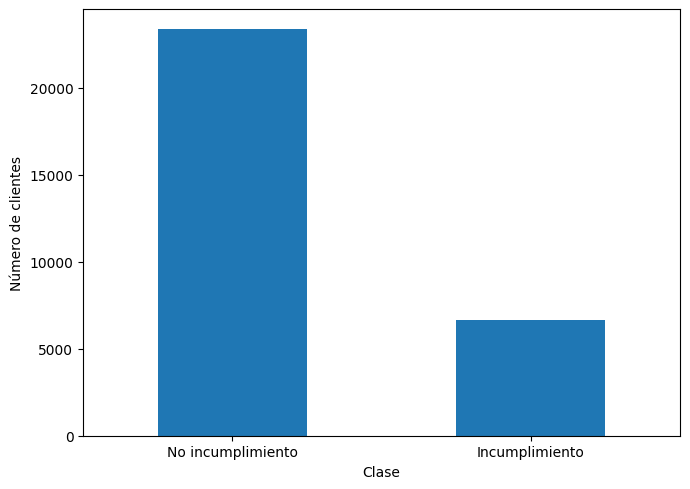

In [9]:
ax = distribucion_abs.plot(kind="bar", figsize=(7, 5))

plt.xlabel("Clase")
plt.ylabel("Número de clientes")
plt.xticks(ticks=[0, 1], labels=["No incumplimiento", "Incumplimiento"], rotation=0)
plt.tight_layout()

plt.savefig(OUTPUT_DIR / "Figura_1_Distribucion_Clases.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Preparación de variables

Se separan las variables predictoras (`X`) y la variable objetivo (`y`). La columna `ID` se elimina porque solo identifica a cada cliente y no aporta información predictiva al modelo.

In [10]:
X = df.drop(columns=["ID", target_col])
y = df[target_col]

print("X:", X.shape)
print("y:", y.shape)

X: (30000, 23)
y: (30000,)


## 5. División entrenamiento-prueba

El conjunto de datos se divide en 80% entrenamiento y 20% prueba. Se utiliza estratificación para conservar la proporción original de clientes con y sin incumplimiento en ambos subconjuntos.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (24000, 23)
X_test: (6000, 23)
y_train: (24000,)
y_test: (6000,)


## 6. Función de evaluación

Para evitar repetir código, se define una función que calcula las métricas principales utilizadas en el artículo: accuracy, precision, recall, F1-score y AUC-ROC.

In [12]:
def evaluar_modelo(nombre_modelo, modelo, X_test, y_test):
    """Calcula métricas de clasificación para un modelo entrenado."""
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    metricas = {
        "Modelo": nombre_modelo,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob)
    }

    return metricas, y_pred, y_prob

## 7. Entrenamiento de modelos

Se entrenan tres modelos de clasificación. La Regresión Logística se utiliza como modelo base tradicional; Random Forest y XGBoost se incorporan como modelos de ensamble.

### 7.1 Regresión Logística

La Regresión Logística se implementa dentro de un `Pipeline` que incluye estandarización de variables. Esto es recomendable porque el modelo es sensible a la escala de los predictores.

In [13]:
modelo_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

modelo_lr.fit(X_train, y_train)

metricas_lr, y_pred_lr, y_prob_lr = evaluar_modelo(
    "Regresión Logística",
    modelo_lr,
    X_test,
    y_test
)

metricas_lr

{'Modelo': 'Regresión Logística',
 'Accuracy': 0.8076666666666666,
 'Precision': 0.6868250539956804,
 'Recall': 0.23963828183873398,
 'F1-score': 0.3553072625698324,
 'AUC-ROC': np.float64(0.7076355036089734)}

In [14]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



### 7.2 Random Forest

Random Forest combina múltiples árboles de decisión. Se utiliza `class_weight='balanced'` para considerar el desbalance entre clientes con y sin incumplimiento.

In [15]:
modelo_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

modelo_rf.fit(X_train, y_train)

metricas_rf, y_pred_rf, y_prob_rf = evaluar_modelo(
    "Random Forest",
    modelo_rf,
    X_test,
    y_test
)

metricas_rf

{'Modelo': 'Random Forest',
 'Accuracy': 0.8145,
 'Precision': 0.6486111111111111,
 'Recall': 0.3519216277317257,
 'F1-score': 0.4562774792379091,
 'AUC-ROC': np.float64(0.7578613436291891)}

In [16]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.65      0.35      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.80      0.81      0.79      6000



### 7.3 XGBoost

XGBoost es un modelo de ensamble basado en gradient boosting. Fue incluido por su uso frecuente en problemas de clasificación financiera y riesgo crediticio.

In [17]:
modelo_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

modelo_xgb.fit(X_train, y_train)

metricas_xgb, y_pred_xgb, y_prob_xgb = evaluar_modelo(
    "XGBoost",
    modelo_xgb,
    X_test,
    y_test
)

metricas_xgb

{'Modelo': 'XGBoost',
 'Accuracy': 0.8185,
 'Precision': 0.6608108108108108,
 'Recall': 0.36850037678975134,
 'F1-score': 0.4731494920174166,
 'AUC-ROC': np.float64(0.7753104262150845)}

In [18]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.37      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000



## 8. Comparación inicial de modelos

Se integran las métricas de los tres modelos en una tabla comparativa.

In [19]:
resultados = pd.DataFrame([
    metricas_lr,
    metricas_rf,
    metricas_xgb
])

resultados_redondeados = resultados.copy()

for col in ["Accuracy", "Precision", "Recall", "F1-score", "AUC-ROC"]:
    resultados_redondeados[col] = resultados_redondeados[col].round(4)

resultados_redondeados

,Modelo,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,Regresión Logística,0.8077,0.6868,0.2396,0.3553,0.7076
1,Random Forest,0.8145,0.6486,0.3519,0.4563,0.7579
2,XGBoost,0.8185,0.6608,0.3685,0.4731,0.7753


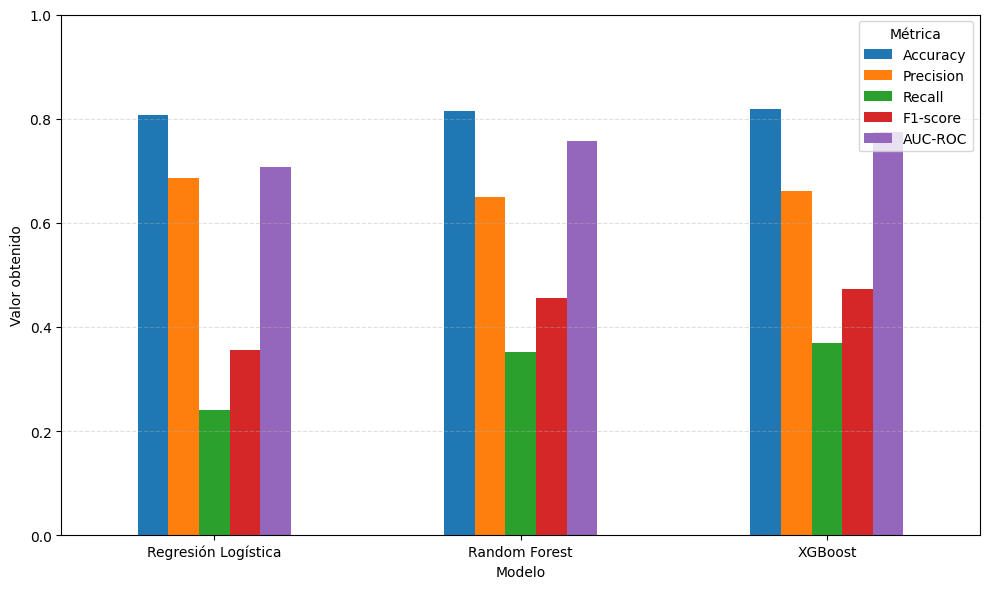

In [20]:
resultados_grafica = resultados_redondeados.set_index("Modelo")

ax = resultados_grafica.plot(kind="bar", figsize=(10, 6))

plt.xlabel("Modelo")
plt.ylabel("Valor obtenido")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="Métrica")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig(OUTPUT_DIR / "Figura_2_Comparacion_Modelos.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Validación cruzada estratificada

Para evaluar la estabilidad de los modelos, se aplica validación cruzada estratificada de cinco particiones. Este procedimiento mantiene la proporción de clases en cada partición y reduce la dependencia de una única división entrenamiento-prueba.

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1-score": "f1",
    "AUC-ROC": "roc_auc"
}

modelos = {
    "Regresión Logística": modelo_lr,
    "Random Forest": modelo_rf,
    "XGBoost": modelo_xgb
}

resultados_cv = []

for nombre, modelo in modelos.items():
    scores = cross_validate(
        modelo,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    fila = {"Modelo": nombre}

    for metrica in scoring.keys():
        valores = scores[f"test_{metrica}"]
        fila[f"{metrica} media"] = valores.mean()
        fila[f"{metrica} desv. est."] = valores.std()

    resultados_cv.append(fila)

resultados_cv = pd.DataFrame(resultados_cv)
resultados_cv_redondeados = resultados_cv.round(4)

resultados_cv_redondeados

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,Modelo,Accuracy media,Accuracy desv. est.,Precision media,Precision desv. est.,Recall media,Recall desv. est.,F1-score media,F1-score desv. est.,AUC-ROC media,AUC-ROC desv. est.
0,Regresión Logística,0.8110,0.0021,0.7176,0.0141,0.2401,0.0048,0.3598,0.0071,0.7227,0.0039
1,Random Forest,0.8156,0.0030,0.6563,0.0159,0.3496,0.0059,0.4561,0.0067,0.7670,0.0033
2,XGBoost,0.8185,0.0021,0.6611,0.0090,0.3683,0.0052,0.4730,0.0061,0.7793,0.0050


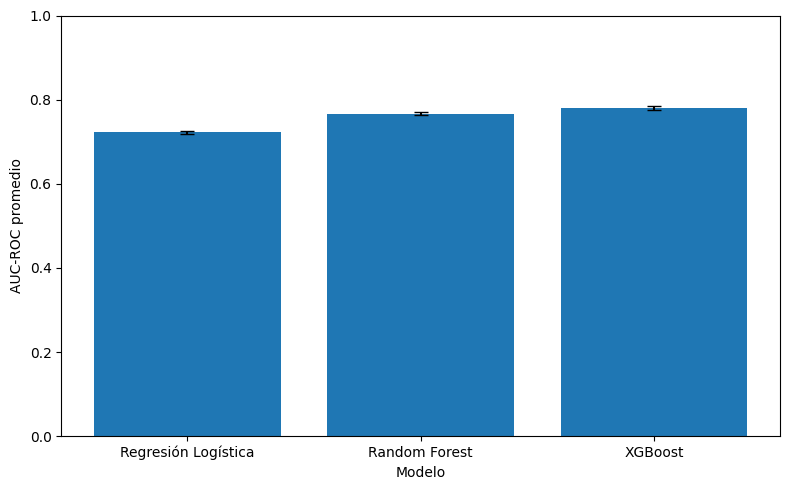

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    resultados_cv_redondeados["Modelo"],
    resultados_cv_redondeados["AUC-ROC media"],
    yerr=resultados_cv_redondeados["AUC-ROC desv. est."],
    capsize=5
)

plt.xlabel("Modelo")
plt.ylabel("AUC-ROC promedio")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(OUTPUT_DIR / "Figura_3_AUC_ROC_Validacion_Cruzada.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Matrices de confusión

Las matrices de confusión permiten observar los verdaderos negativos, falsos positivos, falsos negativos y verdaderos positivos de cada modelo.

In [23]:
predicciones = {
    "Regresión Logística": y_pred_lr,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

resumen_cm = []

for nombre, y_pred in predicciones.items():
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    resumen_cm.append({
        "Modelo": nombre,
        "Verdaderos negativos": tn,
        "Falsos positivos": fp,
        "Falsos negativos": fn,
        "Verdaderos positivos": tp
    })

resumen_cm = pd.DataFrame(resumen_cm)
resumen_cm

,Modelo,Verdaderos negativos,Falsos positivos,Falsos negativos,Verdaderos positivos
0,Regresión Logística,4528,145,1009,318
1,Random Forest,4420,253,860,467
2,XGBoost,4422,251,838,489


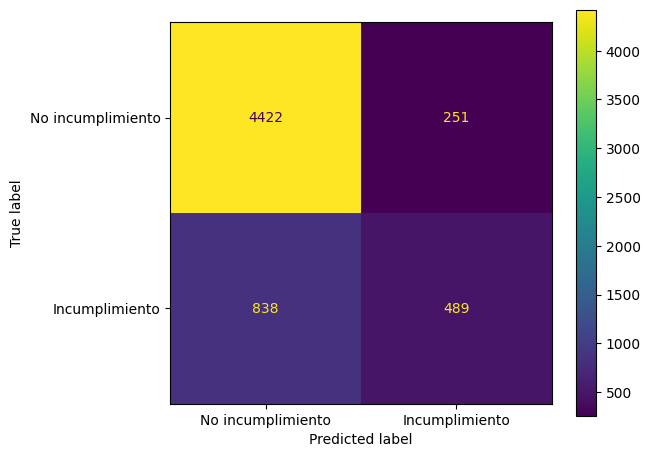

In [24]:
# Matriz de confusión del modelo XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["No incumplimiento", "Incumplimiento"]
)

disp.plot(values_format="d")
plt.tight_layout()

plt.savefig(OUTPUT_DIR / "Figura_4_Matriz_Confusion_XGBoost.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Importancia de variables con XGBoost

Se calcula la importancia de variables del modelo XGBoost para identificar los predictores con mayor contribución en la clasificación del incumplimiento.

In [25]:
importancia_xgb = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_xgb.feature_importances_
})

importancia_xgb = importancia_xgb.sort_values(
    by="Importancia",
    ascending=False
)

importancia_xgb.head(10)

,Variable,Importancia
5,PAY_0,0.311517
6,PAY_2,0.191986
7,PAY_3,0.071473
8,PAY_4,0.039033
9,PAY_5,0.038644
10,PAY_6,0.027709
0,LIMIT_BAL,0.023442
19,PAY_AMT3,0.023206
18,PAY_AMT2,0.022753
11,BILL_AMT1,0.021730


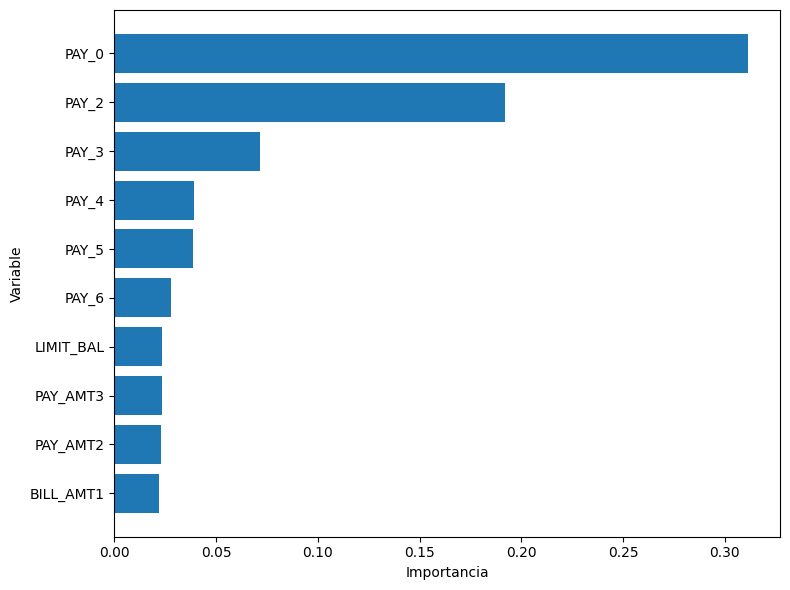

In [26]:
top_10_variables = importancia_xgb.head(10).sort_values(
    by="Importancia",
    ascending=True
)

plt.figure(figsize=(8, 6))
plt.barh(top_10_variables["Variable"], top_10_variables["Importancia"])
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()

plt.savefig(OUTPUT_DIR / "Figura_Importancia_Variables_XGBoost.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. Exportación de resultados

Esta sección guarda las tablas principales en archivos `.csv`, útiles para respaldar los resultados reportados en el artículo.

In [27]:
resultados_redondeados.to_csv("resultados_modelos.csv", index=False)
resultados_cv_redondeados.to_csv("resultados_validacion_cruzada.csv", index=False)
resumen_cm.to_csv("resumen_matrices_confusion.csv", index=False)
importancia_xgb.head(10).to_csv("importancia_variables_xgboost_top10.csv", index=False)

print("Archivos exportados correctamente.")

Archivos exportados correctamente.


## 13. Nota de reproducibilidad

Los resultados pueden presentar variaciones mínimas dependiendo de la versión de las bibliotecas utilizadas. Para reducir estas diferencias, se fijó `RANDOM_STATE = 42` y se documentaron los parámetros principales de cada modelo.